🚀 Post-Quantum Cryptography Benchmark Suite

         Algorithm  Avg Time (ms) Security Level
0   Kyber512 (sim)          0.086        NIST L1
1   Kyber768 (sim)          0.014        NIST L3
2  Kyber1024 (sim)          0.014        NIST L5


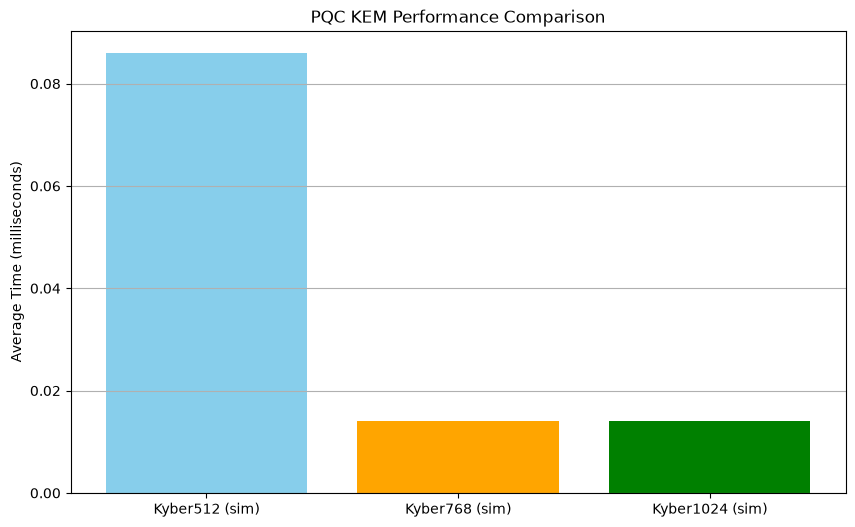


✅ Benchmark saved to pqc_benchmark_results.csv


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

print("🚀 Post-Quantum Cryptography Benchmark Suite\n")

algorithms = ["Kyber512 (sim)", "Kyber768 (sim)", "Kyber1024 (sim)"]
results = []

for alg in algorithms:
    times = []
    for i in range(100):
        start = time.time()
        salt = b'pq_benchmark_salt'
        ikm = b'secret_' + alg.encode() + i.to_bytes(4, 'big')
        hkdf = HKDF(hashes.SHA256(), 32, salt, b'')
        shared = hkdf.derive(ikm)
        times.append(time.time() - start)
    
    avg_time = np.mean(times) * 1000
    results.append({
        "Algorithm": alg,
        "Avg Time (ms)": round(avg_time, 3),
        "Security Level": "NIST L1" if "512" in alg else "NIST L3" if "768" in alg else "NIST L5"
    })

# Create comparison table
df = pd.DataFrame(results)
print(df)

# Plot
plt.figure(figsize=(10, 6))
times_ms = [r["Avg Time (ms)"] for r in results]
plt.bar(algorithms, times_ms, color=['skyblue', 'orange', 'green'])
plt.title("PQC KEM Performance Comparison")
plt.ylabel("Average Time (milliseconds)")
plt.grid(axis='y')
plt.show()

# Save table as CSV for portfolio
df.to_csv("pqc_benchmark_results.csv", index=False)
print("\n✅ Benchmark saved to pqc_benchmark_results.csv")